<a href="https://colab.research.google.com/github/Sharddha-Sharddha/IITMLAssignments/blob/main/Air_passengers_TimeSeriesHandson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# DataSet -> https://drive.google.com/file/d/1nDdOM0ww0dM4vViMptnpIZhz63lVp23K/view

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv('/content/AirPassengers (2).csv')

In [ ]:
data

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


**Problem Statement**

We need to predict future airline passenger number using past data. The dataset has yearly data with the number of passengers recorded over time

In [ ]:
data.isnull().sum()

,0
Month,0
#Passengers,0


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [ ]:
# month column looks like text , so we need to convert it to datetime
# Because time series model needs to understand the order of time

In [ ]:
# convert the data type of month column-
data['Month'] = pd.to_datetime(data['Month'])

In [ ]:
data

,Month,#Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        144 non-null    datetime64[ns]
 1   #Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


In [ ]:
data.set_index('Month',inplace=True)

In [ ]:
data

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   #Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


In [ ]:
# When we set Month column as index -> it moves month column to the index position
# so they appear repeated visually while the actual data remains unique

**Let's check the components of Time Components**

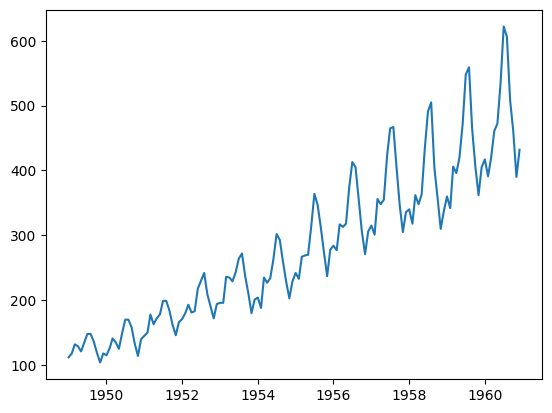

In [ ]:
plt.plot(data['#Passengers'])
plt.show()

**1- Trend-** The overall upward movement from left to right indicates a clear increasing trend

**2- Seasonaility-** The repeating wave-like pattern each year suggests strong seasonality

In [ ]:
# seasonal decompose to check the presence of the component of Time Series
from statsmodels.tsa.seasonal import seasonal_decompose

Figure(640x480)


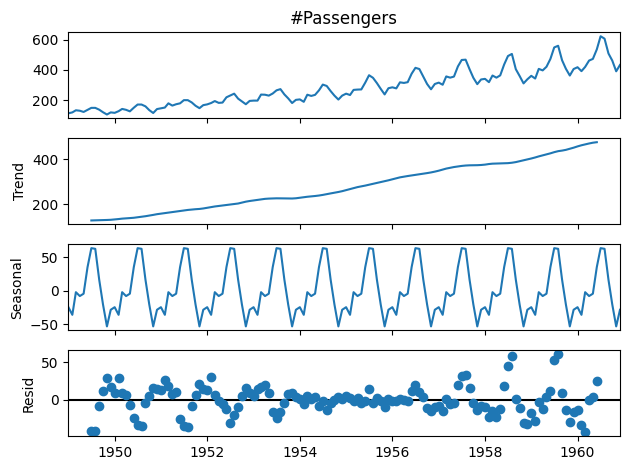

In [ ]:
decompose = seasonal_decompose(data['#Passengers'])
print(decompose.plot())

In [ ]:
# yes we have trend in our data
# yes we have seasonality in our data
# yes we have residual/noise in our data

**Check whether data is stationary ??**

- Stationary data means whose statistical properties do not change over time

- no trend , no seasonality

In [ ]:
# Stationary = Stable data

**ADF Test**

The ADF Test (Augmented Dickey-fuller Test) is a statistical test used to check if a time series is stationary or not

In [ ]:
# p-value >0.05  --> data is non - stationary
# p-value <0.05  --> data is a stationary

In [ ]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
result = adfuller(data['#Passengers'])
result

(np.float64(0.8153688792060498),
 np.float64(0.991880243437641),
 13,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(996.692930839019))

**the second value in this result shows our p-value**

In [ ]:
p_value = result[1]
p_value

np.float64(0.991880243437641)

**here p-value is > 0.05** (non-stationary data)

In [ ]:
# if we have non - stationary data then we have to make it stationary

**Rolling Mean (moving average)-** It calculate the average of a specific number of data points (called the window) as it moves through the data.

ex - [10,20,30,40,50,60]

window size = 3

- first window = (10,20,30)

- second window = (20,30,40)

- third window = (30,40,50)

- fourth window = (40,50,60)

In [ ]:
mean = data.rolling(window=12).mean()
std = data.rolling(window=12).std()

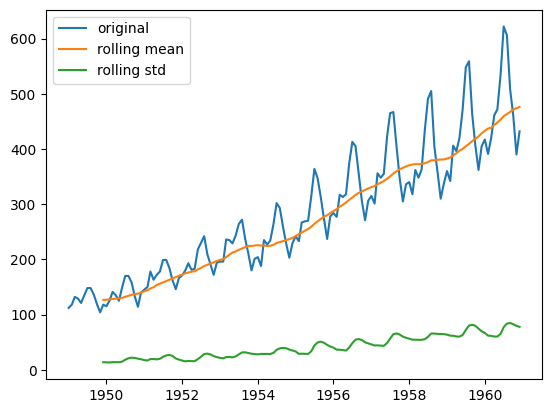

In [ ]:
plt.plot(data,label = 'original')
plt.plot(mean , label='rolling mean')
plt.plot(std , label = 'rolling std')
plt.legend()

In [ ]:
# Log transformation ->  it stablizes the variance (exponential growth) , compress the data

In [ ]:
log_df = np.log(data)

<Axes: xlabel='Month'>

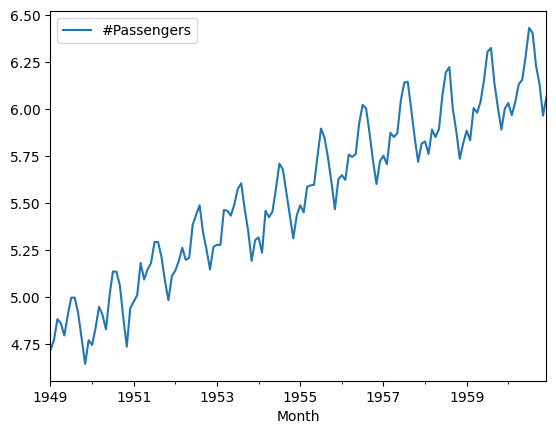

In [ ]:
log_df.plot()

In [ ]:
log_df

,#Passengers
Month,
1949-01-01,4.718499
1949-02-01,4.770685
1949-03-01,4.882802
1949-04-01,4.859812
1949-05-01,4.795791
...,...
1960-08-01,6.406880
1960-09-01,6.230481
1960-10-01,6.133398


In [ ]:
# again try adf test-
result1 = adfuller(log_df.dropna())
result1

(np.float64(-1.7170170891069683),
 np.float64(0.4223667747703874),
 13,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(-445.3990312497209))

In [ ]:
p_value = result1[1]
p_value

np.float64(0.4223667747703874)

In [ ]:
# our data is still non - stationary data

In [ ]:
mean = log_df.rolling(window=12).mean()
std = log_df.rolling(window=12).std()

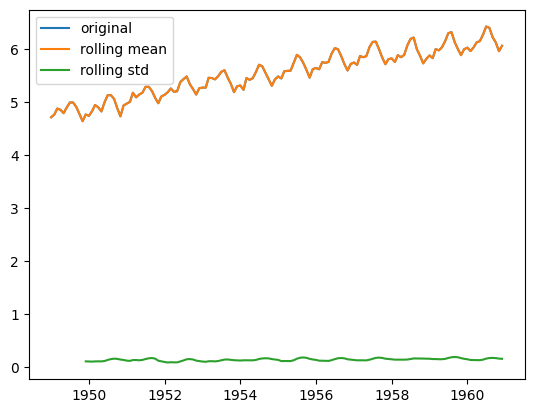

In [ ]:
plt.plot(log_df,label = 'original')
plt.plot(log_df , label='rolling mean')
plt.plot(std , label = 'rolling std')
plt.legend()

In [ ]:
# differencing-
new_data = log_df - mean  # original data - rolling mean
new_data = new_data.dropna()
new_data

,#Passengers
Month,
1949-12-01,-0.065494
1950-01-01,-0.093449
1950-02-01,-0.007566
1950-03-01,0.099416
1950-04-01,0.052142
...,...
1960-08-01,0.282363
1960-09-01,0.098235
1960-10-01,-0.009230


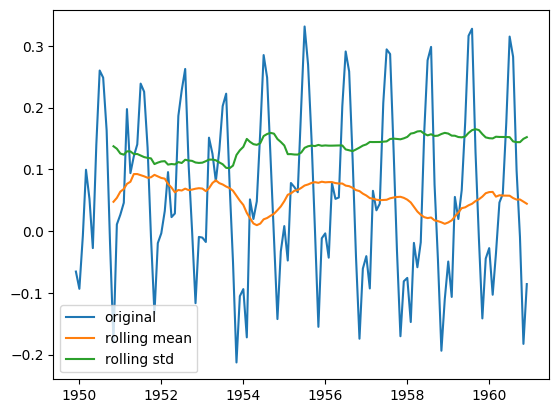

In [ ]:
mean = new_data.rolling(window=12).mean()
std = new_data.rolling(window=12).std()
plt.plot(new_data,label = 'original')
plt.plot(mean , label='rolling mean')
plt.plot(std , label = 'rolling std')
plt.legend()


In [ ]:
# again try adf test-
result2 = adfuller(new_data.dropna())
result2

(np.float64(-3.1629079913008833),
 np.float64(0.022234630001242206),
 13,
 119,
 {'1%': np.float64(-3.4865346059036564),
  '5%': np.float64(-2.8861509858476264),
  '10%': np.float64(-2.579896092790057)},
 np.float64(-436.63269481747034))

In [ ]:
p_value = result2[1]
p_value

np.float64(0.022234630001242206)

In [ ]:
# NOW OUR DATA IS STATIONARY

In [ ]:
new_data.shape

(133, 1)

In [ ]:
# divide the data into train and test-
train = new_data.iloc[:106]['#Passengers'] # nearly 80 %
test = new_data.iloc[106:]['#Passengers']

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf , plot_acf

In [ ]:
# What is PACF?
# It stands for Partial Correlation Function
# it shows direct relationship , removing middle effects
# it will give the p value

In [ ]:
# Lag = how many times steps back
# ex - if we have monthly data
# Lag1 -> previous month
# Lag2 -> 2 months ago
# Lag3 -> 3 months ago

In [ ]:
# What is ACF?
# It stands for AutoCorrelation function
# it will give q value
# it show indirect relationship
# it shows how current value is related to past values

In [ ]:
# x - axis = lags
# y-axis = correlation

<Figure size 1500x800 with 0 Axes>

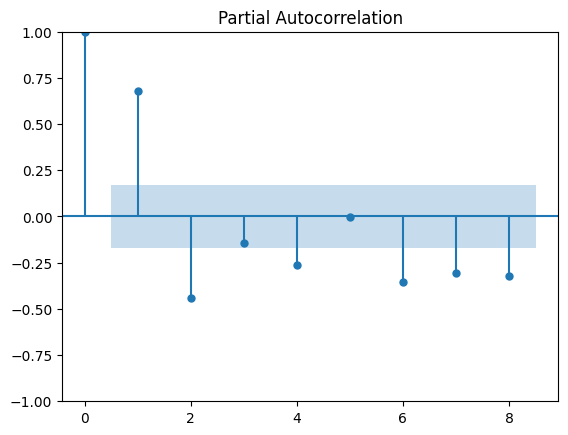

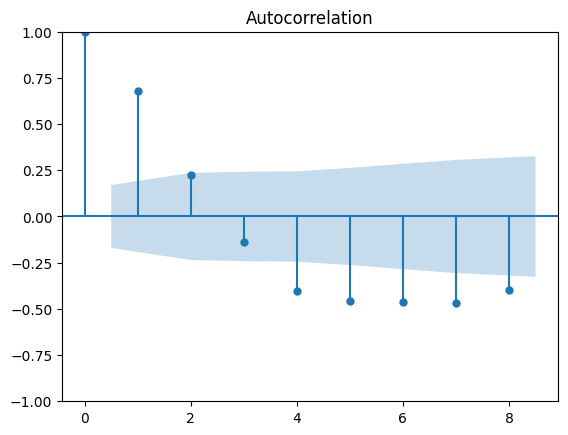

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
plt.figure(figsize=(15,8))
plot_pacf(new_data , lags = 8)
plot_acf (new_data , lags= 8)
plt.show()

In [ ]:
# IN PLOTS -> blue region is known as confidence interval
# bars outside the confidence interval -> more significant
# bars inside the confide interval -> less significant

In [ ]:
# Airpassenger = monthly data
# seasonality = 12 month

In [ ]:
# ARIMA -> Auto Regressive Integerated Moving Average
# p , d , q
# auto regressive -> p
# q -> ma (moving average)
# d -> differencing

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals

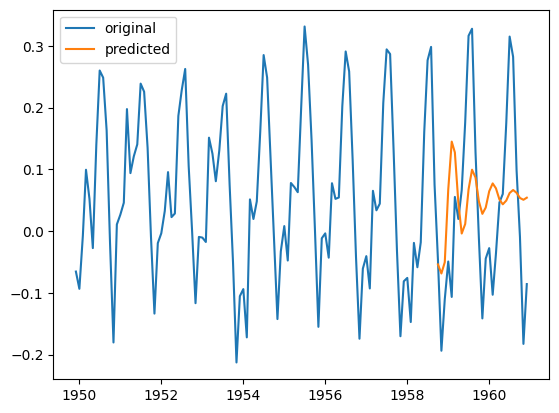

In [ ]:
ar = ARIMA(train , order=(3,1,5))
ar_result = ar.fit()
new_data['predict_ar'] = ar_result.predict(start = len(train), end= len(train)+len(test)-1,dynamic=False)
plt.plot(new_data['#Passengers'],label='original')
plt.plot(new_data['predict_ar'],label='predicted')
plt.legend()
plt.show()

In [ ]:
# how to select optimal values for p and q
# Itertools -> tries many combinations and evaluate the model to give the optimal result

In [ ]:
# we want optimal value for our p ,d ,q
from sklearn.metrics import *
import itertools
p = range(0,8) # 0 , 1 , 2 , 3 , 4 , 5 , 6 , 7
d = range(1,2) # 1
q = range(0,8)

pdq = list(itertools.product(p,d,q)) # create all possible combintion of (p,d,q)
# pdq -> (0,1,0),(0,1,1),(0,1,2),(0,1,3).....................................
rmse = [] # empty list to store rmse value
order1 = []  # store order for p,d,q
for i in pdq:
  model = ARIMA(train , order=i) # we are creating arima model
  model_fit = model.fit()
  pred = model_fit.predict(start= len(train) , end = len(train)+ len(test)-1)
  error = np.sqrt(mean_squared_error(test,pred))
  order1.append(i)
  rmse.append(error)

results = pd.DataFrame(index= order1 , data=rmse, columns=['RMSE'])


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

In [ ]:
pdq

[(0, 1, 0),
 (0, 1, 1),
 (0, 1, 2),
 (0, 1, 3),
 (0, 1, 4),
 (0, 1, 5),
 (0, 1, 6),
 (0, 1, 7),
 (1, 1, 0),
 (1, 1, 1),
 (1, 1, 2),
 (1, 1, 3),
 (1, 1, 4),
 (1, 1, 5),
 (1, 1, 6),
 (1, 1, 7),
 (2, 1, 0),
 (2, 1, 1),
 (2, 1, 2),
 (2, 1, 3),
 (2, 1, 4),
 (2, 1, 5),
 (2, 1, 6),
 (2, 1, 7),
 (3, 1, 0),
 (3, 1, 1),
 (3, 1, 2),
 (3, 1, 3),
 (3, 1, 4),
 (3, 1, 5),
 (3, 1, 6),
 (3, 1, 7),
 (4, 1, 0),
 (4, 1, 1),
 (4, 1, 2),
 (4, 1, 3),
 (4, 1, 4),
 (4, 1, 5),
 (4, 1, 6),
 (4, 1, 7),
 (5, 1, 0),
 (5, 1, 1),
 (5, 1, 2),
 (5, 1, 3),
 (5, 1, 4),
 (5, 1, 5),
 (5, 1, 6),
 (5, 1, 7),
 (6, 1, 0),
 (6, 1, 1),
 (6, 1, 2),
 (6, 1, 3),
 (6, 1, 4),
 (6, 1, 5),
 (6, 1, 6),
 (6, 1, 7),
 (7, 1, 0),
 (7, 1, 1),
 (7, 1, 2),
 (7, 1, 3),
 (7, 1, 4),
 (7, 1, 5),
 (7, 1, 6),
 (7, 1, 7)]

In [ ]:
order1

[(0, 1, 0),
 (0, 1, 1),
 (0, 1, 2),
 (0, 1, 3),
 (0, 1, 4),
 (0, 1, 5),
 (0, 1, 6),
 (0, 1, 7),
 (1, 1, 0),
 (1, 1, 1),
 (1, 1, 2),
 (1, 1, 3),
 (1, 1, 4),
 (1, 1, 5),
 (1, 1, 6),
 (1, 1, 7),
 (2, 1, 0),
 (2, 1, 1),
 (2, 1, 2),
 (2, 1, 3),
 (2, 1, 4),
 (2, 1, 5),
 (2, 1, 6),
 (2, 1, 7),
 (3, 1, 0),
 (3, 1, 1),
 (3, 1, 2),
 (3, 1, 3),
 (3, 1, 4),
 (3, 1, 5),
 (3, 1, 6),
 (3, 1, 7),
 (4, 1, 0),
 (4, 1, 1),
 (4, 1, 2),
 (4, 1, 3),
 (4, 1, 4),
 (4, 1, 5),
 (4, 1, 6),
 (4, 1, 7),
 (5, 1, 0),
 (5, 1, 1),
 (5, 1, 2),
 (5, 1, 3),
 (5, 1, 4),
 (5, 1, 5),
 (5, 1, 6),
 (5, 1, 7),
 (6, 1, 0),
 (6, 1, 1),
 (6, 1, 2),
 (6, 1, 3),
 (6, 1, 4),
 (6, 1, 5),
 (6, 1, 6),
 (6, 1, 7),
 (7, 1, 0),
 (7, 1, 1),
 (7, 1, 2),
 (7, 1, 3),
 (7, 1, 4),
 (7, 1, 5),
 (7, 1, 6),
 (7, 1, 7)]

In [ ]:
results.sort_values(by = 'RMSE' , ascending = True)

,RMSE
"(7, 1, 5)",0.068655
"(5, 1, 7)",0.071788
"(6, 1, 7)",0.073744
"(7, 1, 6)",0.075850
"(4, 1, 7)",0.076456
...,...
"(2, 1, 7)",0.149920
"(0, 1, 1)",0.150150
"(2, 1, 0)",0.151556
"(3, 1, 0)",0.151889


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals

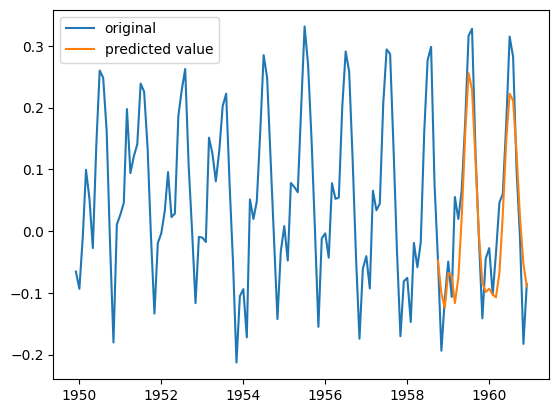

In [ ]:
arima1 = ARIMA(train , order=(7,1,5))
arima_result1 = arima1.fit()
new_data['predict_arima1']= arima_result1.predict(start=len(train),end=len(train)+len(test)-1,dynamic=False)
plt.plot(new_data['#Passengers'], label = 'original')
plt.plot(new_data['predict_arima1'], label = 'predicted value')
plt.legend()
plt.show()